### 2.1 第1小题：无激活函数的MLP等价于单层网络

已知：
隐藏层：h = W1*x + b1 （无激活函数，线性变换）
输出层：o = W2*h + b2

推导：
o = W2*(W1*x + b1) + b2
  = W2*W1*x + W2*b1 + b2
  = W'*x + b'

其中：
W' = W2*W1
b' = W2*b1 + b2

结论：多个线性变换的复合仍然是线性变换，因此该网络等价于单层神经网络。
等价权重矩阵 W' = W2*W1
等价偏置向量 b' = W2*b1 + b2

这也说明了非线性激活函数的重要性：如果没有激活函数，无论堆叠多少层，
多层感知机都只能表示线性映射，无法学习非线性关系。

### 2.1 第2小题：Sigmoid 和 Tanh 的导数推导

---

#### Sigmoid 函数

表达式：
Sigmoid(x) = 1 / (1 + e^(-x))

导数推导：
Sigmoid'(x) = d/dx [1/(1+e^(-x))]
            = e^(-x) / (1+e^(-x))^2
            = 1/(1+e^(-x)) * e^(-x)/(1+e^(-x))
            = 1/(1+e^(-x)) * (1 - 1/(1+e^(-x)))
            = Sigmoid(x) * (1 - Sigmoid(x))

结论：Sigmoid'(x) = Sigmoid(x) * (1 - Sigmoid(x))
即 Sigmoid 的导数可以用自身表示。

---

#### Tanh 函数

表达式：
tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))

导数推导：
tanh'(x) = 1 - tanh^2(x)
（由双曲函数恒等式得出）

结论：tanh'(x) = 1 - tanh^2(x)
即 tanh 的导数也可以用自身表示。

---

#### 意义：
这两个激活函数的导数都能用自身表达，在反向传播中计算方便。
但 Sigmoid 的导数最大值为 0.25，在深层网络中容易导致梯度消失；
tanh 的导数最大值为 1，梯度消失问题相对较轻，但仍然存在。

正在加载 Fashion-MNIST 数据...


d:\anaconda\Lib\site-packages\sklearn\datasets\_openml.py:74: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


训练集: (60000, 784), 测试集: (10000, 784)
类别数: 10

W1: (784, 256), b1: (1, 256)
W2: (256, 10), b2: (1, 10)
Epoch 5/30, Loss: 0.3519, Test Acc: 0.8672
Epoch 10/30, Loss: 0.2935, Test Acc: 0.8775
Epoch 15/30, Loss: 0.2579, Test Acc: 0.8676
Epoch 20/30, Loss: 0.2296, Test Acc: 0.8772
Epoch 25/30, Loss: 0.2089, Test Acc: 0.8913
Epoch 30/30, Loss: 0.1914, Test Acc: 0.8882

最终测试集准确率: 0.8882


C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\4176939922.py:139: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}

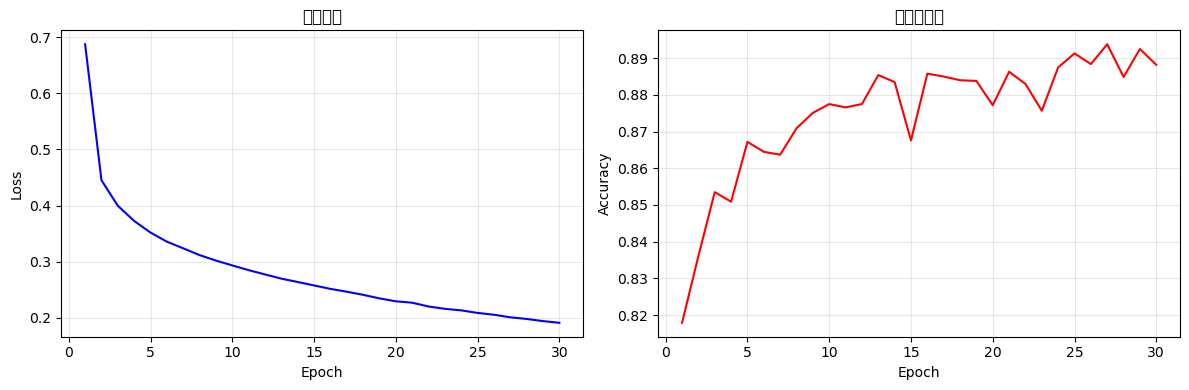

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# ============================================
# 1. 加载 Fashion-MNIST 数据
# ============================================
print("正在加载 Fashion-MNIST 数据...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

def one_hot(y, num_classes=10):
    n = len(y)
    onehot = np.zeros((n, num_classes))
    onehot[np.arange(n), y] = 1
    return onehot

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"类别数: 10")

# ============================================
# 2. 定义激活函数和损失函数
# ============================================
def relu(x):
    return np.maximum(0, x)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.sum(y_true * np.log(y_pred)) / y_pred.shape[0]

# ============================================
# 3. 初始化参数
# ============================================
np.random.seed(42)

input_size = 784
hidden_size = 256
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

print(f"\nW1: {W1.shape}, b1: {b1.shape}")
print(f"W2: {W2.shape}, b2: {b2.shape}")

# ============================================
# 4. 训练循环
# ============================================
lr = 0.1
batch_size = 64
epochs = 30
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    epoch_loss = 0
    num_batches = 0
    
    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]
        X_batch = X_train[batch_idx]
        y_batch = y_train_oh[batch_idx]
        
        # 前向
        z1 = X_batch @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        y_pred = softmax(z2)
        
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向
        grad_z2 = y_pred - y_batch
        grad_W2 = a1.T @ grad_z2 / batch_size
        grad_b2 = np.sum(grad_z2, axis=0, keepdims=True) / batch_size
        
        grad_a1 = grad_z2 @ W2.T
        grad_z1 = grad_a1 * (z1 > 0)
        grad_W1 = X_batch.T @ grad_z1 / batch_size
        grad_b1 = np.sum(grad_z1, axis=0, keepdims=True) / batch_size
        
        # 更新
        W1 -= lr * grad_W1
        b1 -= lr * grad_b1
        W2 -= lr * grad_W2
        b2 -= lr * grad_b2
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # 测试
    z1_test = X_test @ W1 + b1
    a1_test = relu(z1_test)
    z2_test = a1_test @ W2 + b2
    y_test_pred = softmax(z2_test)
    test_acc = np.mean(np.argmax(y_test_pred, axis=1) == y_test)
    test_accuracies.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {test_acc:.4f}")

print(f"\n最终测试集准确率: {test_accuracies[-1]:.4f}")

# ============================================
# 5. 绘制曲线
# ============================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), test_accuracies, 'r-')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('测试准确率')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 第1小题：过拟合与欠拟合

---

#### 训练误差与泛化误差的区别：

训练误差（Training Error）：模型在训练数据集上计算得到的误差，反映模型对已见数据的拟合程度。

泛化误差（Generalization Error）：模型在未见过的测试数据集上的误差，反映模型对未知数据的预测能力。

---

#### 过拟合状态：

当训练误差极低，但泛化误差很高时，模型处于**过拟合**状态。
此时模型过度记忆了训练数据中的噪声和细节模式，而非学习到数据的真实分布规律。

---

#### 通过控制模型复杂度缓解过拟合：

1. 减少模型参数数量：降低网络层数或每层神经元数，减少模型容量
2. 正则化技术：L1/L2 正则化（权重衰减）限制参数大小
3. Dropout：训练时随机丢弃部分神经元，防止特征依赖
4. 早停法：在验证误差开始上升时停止训练
5. 增加训练数据：收集更多样本或使用数据增强
6. 降低模型复杂度：使用更简单的模型结构

---

#### 欠拟合状态（补充）：

当训练误差和泛化误差都很高时，模型处于**欠拟合**状态。
此时模型容量不足，无法捕捉数据中的基本规律。
缓解方法：增加模型容量（更多层、更多神经元）、添加特征、减少正则化强度。

### 3.1 第2小题：K折交叉验证

K折交叉验证（K-fold Cross-Validation）是一种评估模型泛化能力的方法，算法步骤如下：

---

#### 算法步骤：

第1步：将原始数据集随机打乱，均等划分为 K 个互不相交的子集（折）。

第2步：进行 K 轮训练和评估：
  - 对于 i = 1, 2, ..., K：
    - 选择第 i 个子集作为验证集
    - 其余 K-1 个子集合并作为训练集
    - 在训练集上训练模型
    - 在验证集上评估模型，记录验证分数 Ei

第3步：计算 K 次验证分数的平均值作为最终评估结果：
  E = (1/K) * Σ Ei

第4步：计算验证分数的标准差，评估模型性能的稳定性。

---

#### 说明：

- K 的典型取值为 5 或 10
- 当 K = n（样本数）时，称为留一交叉验证（Leave-One-Out CV）
- 优点：每个样本都有机会被用作验证，数据利用率高
- 缺点：计算成本较高，需要训练 K 次模型
- 使用场景：数据集较小，需要可靠评估模型性能时使用

正在加载 Fashion-MNIST 数据...
训练集: (1500, 784), 验证集: (500, 784), 测试集: (5000, 784)

训练模型1：无正则化

训练模型2：仅权重衰减

训练模型3：仅 Dropout


C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\400805746.py:208: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) miss

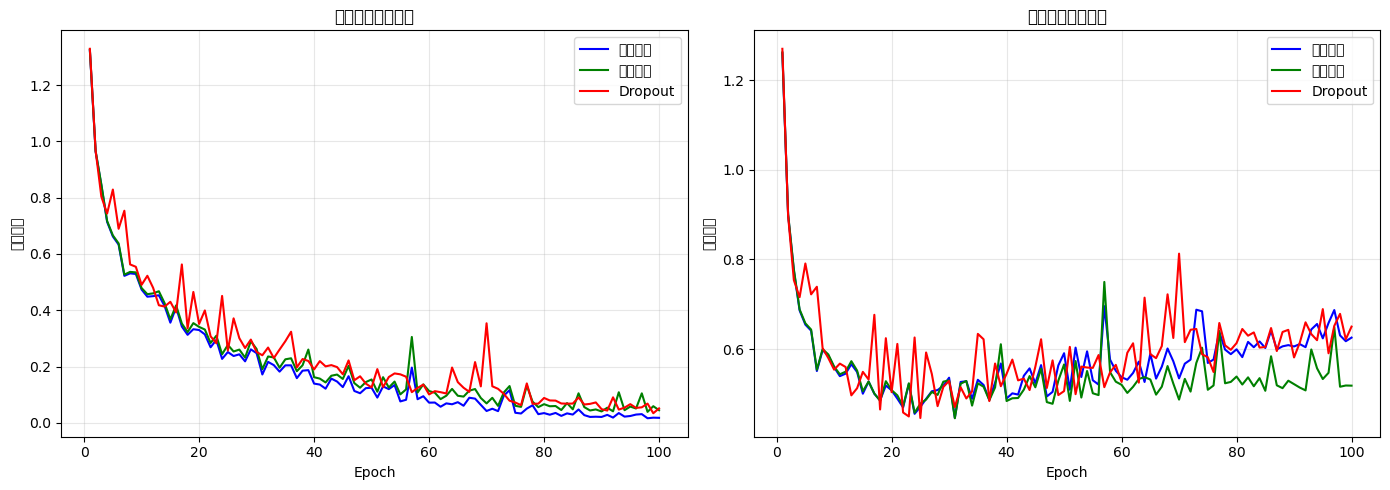


最终验证损失对比：
无正则化 - 训练损失: 0.0179, 验证损失: 0.6256
权重衰减 - 训练损失: 0.0449, 验证损失: 0.5184
Dropout  - 训练损失: 0.0514, 验证损失: 0.6502


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# ============================================
# 1. 加载数据（取少量样本制造过拟合场景）
# ============================================
print("正在加载 Fashion-MNIST 数据...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

# 只取前2000个训练样本 + 前5000个测试样本
X_train_full = X[:2000]
y_train_full = y[:2000]
X_test = X[60000:65000]
y_test = y[60000:65000]

# 取其中1500个做训练，500个做验证
X_train, y_train = X_train_full[:1500], y_train_full[:1500]
X_val, y_val = X_train_full[1500:], y_train_full[1500:]

def one_hot(y, num_classes=10):
    n = len(y)
    onehot = np.zeros((n, num_classes))
    onehot[np.arange(n), y] = 1
    return onehot

y_train_oh = one_hot(y_train)
y_val_oh = one_hot(y_val)
y_test_oh = one_hot(y_test)

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ============================================
# 2. 定义基础函数
# ============================================
def relu(x):
    return np.maximum(0, x)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.sum(y_true * np.log(y_pred)) / y_pred.shape[0]

def dropout_layer(X, dropout_prob, is_training):
    """
    自定义 Dropout 层
    X: 输入矩阵
    dropout_prob: 丢弃概率
    is_training: 训练模式为 True，测试模式为 False
    """
    if not is_training or dropout_prob == 0:
        return X
    
    # 生成随机掩码
    mask = (np.random.rand(*X.shape) > dropout_prob).astype(np.float32)
    # 缩放：保留的神经元除以 (1-p) 保持期望不变
    scaled_mask = mask / (1.0 - dropout_prob)
    return X * scaled_mask

# ============================================
# 3. 构建训练函数
# ============================================
def train_mlp(X_train, y_train_oh, X_val, y_val_oh,
              use_weight_decay=False, use_dropout=False,
              lr=0.1, batch_size=32, epochs=100,
              weight_decay_lambda=0.001, dropout_prob=0.5):
    
    np.random.seed(42)
    
    input_size = 784
    hidden_size = 256
    output_size = 10
    
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))
        epoch_loss = 0
        num_batches = 0
        
        for start in range(0, len(X_train), batch_size):
            end = min(start + batch_size, len(X_train))
            batch_idx = indices[start:end]
            X_batch = X_train[batch_idx]
            y_batch = y_train_oh[batch_idx]
            
            # ---- 前向传播 ----
            z1 = X_batch @ W1 + b1
            a1 = relu(z1)
            
            # Dropout 放在激活函数之后
            a1 = dropout_layer(a1, dropout_prob if use_dropout else 0, is_training=True)
            
            z2 = a1 @ W2 + b2
            y_pred = softmax(z2)
            
            loss = cross_entropy_loss(y_pred, y_batch)
            
            # 权重衰减的额外损失项（仅用于记录）
            if use_weight_decay:
                loss += 0.5 * weight_decay_lambda * (np.sum(W1**2) + np.sum(W2**2))
            
            epoch_loss += loss
            num_batches += 1
            
            # ---- 反向传播 ----
            grad_z2 = y_pred - y_batch
            grad_W2 = a1.T @ grad_z2 / len(X_batch)
            grad_b2 = np.sum(grad_z2, axis=0, keepdims=True) / len(X_batch)
            
            grad_a1 = grad_z2 @ W2.T
            grad_z1 = grad_a1 * (z1 > 0)
            grad_W1 = X_batch.T @ grad_z1 / len(X_batch)
            grad_b1 = np.sum(grad_z1, axis=0, keepdims=True) / len(X_batch)
            
            # ---- 参数更新 ----
            if use_weight_decay:
                # 权重衰减：W = (1 - lr*lambda)*W - lr*grad
                W1 = (1 - lr * weight_decay_lambda) * W1 - lr * grad_W1
                W2 = (1 - lr * weight_decay_lambda) * W2 - lr * grad_W2
            else:
                W1 -= lr * grad_W1
                W2 -= lr * grad_W2
            
            b1 -= lr * grad_b1
            b2 -= lr * grad_b2
        
        # 计算训练损失
        z1_train = X_train @ W1 + b1
        a1_train = relu(z1_train)
        a1_train = dropout_layer(a1_train, dropout_prob if use_dropout else 0, is_training=False)
        z2_train = a1_train @ W2 + b2
        y_train_pred = softmax(z2_train)
        train_loss = cross_entropy_loss(y_train_pred, y_train_oh)
        train_losses.append(train_loss)
        
        # 计算验证损失
        z1_val = X_val @ W1 + b1
        a1_val = relu(z1_val)
        a1_val = dropout_layer(a1_val, dropout_prob if use_dropout else 0, is_training=False)
        z2_val = a1_val @ W2 + b2
        y_val_pred = softmax(z2_val)
        val_loss = cross_entropy_loss(y_val_pred, y_val_oh)
        val_losses.append(val_loss)
    
    return train_losses, val_losses, W1, b1, W2, b2

# ============================================
# 4. 训练三种模型
# ============================================
print("\n训练模型1：无正则化")
train1, val1, W1_1, b1_1, W2_1, b2_1 = train_mlp(
    X_train, y_train_oh, X_val, y_val_oh,
    use_weight_decay=False, use_dropout=False
)

print("\n训练模型2：仅权重衰减")
train2, val2, W1_2, b1_2, W2_2, b2_2 = train_mlp(
    X_train, y_train_oh, X_val, y_val_oh,
    use_weight_decay=True, use_dropout=False
)

print("\n训练模型3：仅 Dropout")
train3, val3, W1_3, b1_3, W2_3, b2_3 = train_mlp(
    X_train, y_train_oh, X_val, y_val_oh,
    use_weight_decay=False, use_dropout=True
)

# ============================================
# 5. 绘制对比曲线
# ============================================
plt.figure(figsize=(14, 5))

# 训练损失对比
plt.subplot(1, 2, 1)
plt.plot(range(1, 101), train1, 'b-', label='无正则化', linewidth=1.5)
plt.plot(range(1, 101), train2, 'g-', label='权重衰减', linewidth=1.5)
plt.plot(range(1, 101), train3, 'r-', label='Dropout', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('训练损失')
plt.title('训练损失曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 验证损失对比
plt.subplot(1, 2, 2)
plt.plot(range(1, 101), val1, 'b-', label='无正则化', linewidth=1.5)
plt.plot(range(1, 101), val2, 'g-', label='权重衰减', linewidth=1.5)
plt.plot(range(1, 101), val3, 'r-', label='Dropout', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('验证损失')
plt.title('验证损失曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 6. 输出最终结果
# ============================================
print("\n" + "=" * 60)
print("最终验证损失对比：")
print(f"无正则化 - 训练损失: {train1[-1]:.4f}, 验证损失: {val1[-1]:.4f}")
print(f"权重衰减 - 训练损失: {train2[-1]:.4f}, 验证损失: {val2[-1]:.4f}")
print(f"Dropout  - 训练损失: {train3[-1]:.4f}, 验证损失: {val3[-1]:.4f}")
print("=" * 60)

### 4.1 第1小题：梯度消失与梯度爆炸的量化分析

---

考虑深度为 d 的网络，梯度包含连乘项：∏(t=1 to d-1) ∂h_{i+1}/∂h_i

每一层的雅可比矩阵 ∂h_{i+1}/∂h_i 包含两个因素：

#### 因素1：激活函数的导数

- Sigmoid：最大导数为 0.25（在 x=0 处），|Sigmoid'(x)| ≤ 0.25
- Tanh：最大导数为 1（在 x=0 处），|tanh'(x)| ≤ 1
- ReLU：导数为 0 或 1

#### 因素2：权重矩阵的范数

设权重矩阵 W_i 的最大奇异值为 σ_max(W_i)

---

#### 梯度爆炸条件：

若大多数层满足 ||∂h_{i+1}/∂h_i|| > 1，即权重范数较大且激活函数导数接近1，
则连乘 d 层后梯度呈指数级增长：

||梯度|| ∝ O(c^d)，其中 c > 1

出现条件：权重初始化过大，导致 ||W_i|| > 1 持续放大梯度

---

#### 梯度消失条件：

若大多数层满足 ||∂h_{i+1}/∂h_i|| < 1，即权重范数较小或激活函数导数小于1，
则连乘 d 层后梯度呈指数级衰减：

||梯度|| ∝ O(c^d)，其中 c < 1

出现条件：
1. 使用 Sigmoid 激活函数，导数 ≤ 0.25，逐层衰减
2. 权重初始化过小

---

### 4.1 第2小题：ReLU 缓解梯度消失的原因

ReLU 函数定义为：ReLU(x) = max(0, x)
其导数为：ReLU'(x) = 1（当 x > 0），ReLU'(x) = 0（当 x ≤ 0）

缓解梯度消失的关键原因：

1. 正值区域导数为常数1：
   当输入大于0时，ReLU 的导数为1（而非像 Sigmoid 那样小于1）。
   梯度反向传播经过 ReLU 时不会被压缩，可以保持梯度幅值不变。

2. 避免指数衰减：
   对于激活值大于0的神经元，梯度连乘项中 ∂h_{i+1}/∂h_i = W_i · 1 = W_i，
   不再包含小于1的激活函数导数因子，避免了指数级衰减。

3. 稀疏激活的副作用：
   虽然部分神经元输出为0（梯度也为0），但只要网络足够宽，
   总有足够的神经元保持激活状态，梯度可以沿这些路径有效传播。

4. 对比：
   使用 Sigmoid 的 d 层网络，梯度可能衰减为原来的 (0.25)^d
   使用 ReLU 的 d 层网络，正值路径的梯度幅值取决于 W 的范数，
   通过合适的初始化可保持在合理范围。

4.2 数值不稳定实验

实验1：Sigmoid + 普通初始化 N(0, 1)
前5层梯度范数: ['826.437683', '676.598450', '544.970093', '618.397156', '657.793335']
后5层梯度范数: ['36.511456', '28.735283', '20.788364', '14.722697', '12.948808']
是否出现 NaN: False

实验2：ReLU + 大权重初始化 N(0, 10)
前5层梯度范数: ['inf', 'inf', 'inf', 'inf', 'inf']
后5层梯度范数: ['inf', 'inf', 'inf', 'inf', 'nan']
是否出现 NaN: True

实验3：ReLU + Xavier 初始化
前5层梯度范数: ['1.601505', '1.707072', '1.699414', '1.657813', '1.642289']
后5层梯度范数: ['3.571779', '4.149837', '5.165155', '5.096285', '5.008135']
是否出现 NaN: False
梯度范围: [1.364504, 5.165155]

实验4：LeakyReLU + Xavier 初始化
前5层梯度范数: ['1.664175', '1.508009', '1.450894', '1.405294', '1.501094']
后5层梯度范数: ['3.048243', '3.304587', '3.899273', '4.264647', '4.240381']
是否出现 NaN: False
梯度范围: [1.325084, 4.264647]


C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\3740632138.py:194: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}

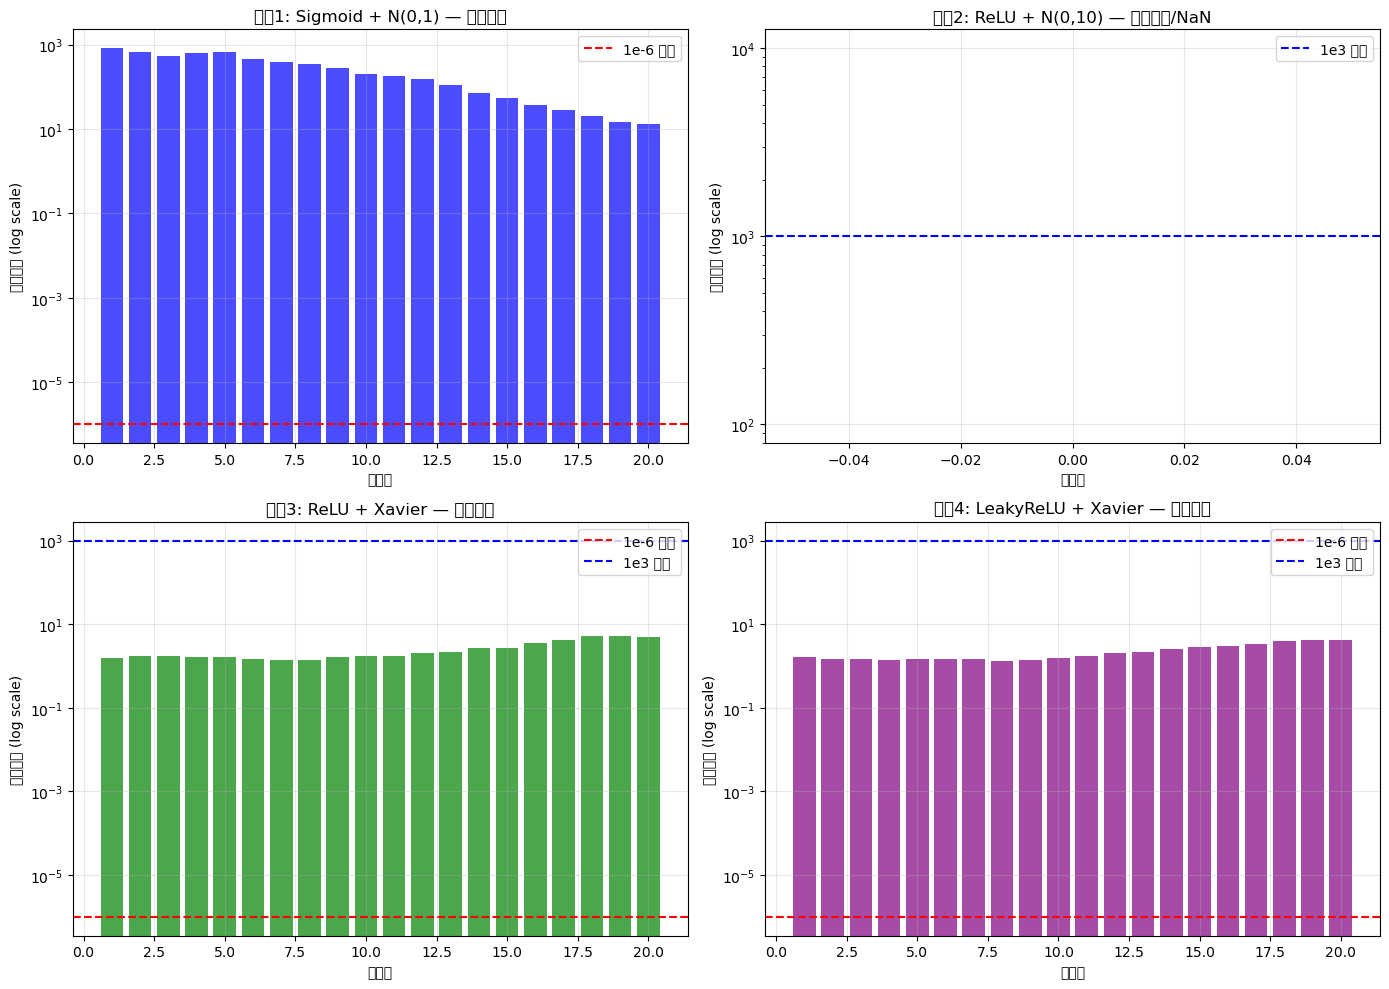


总结：
1. Sigmoid+普通初始化 → 梯度消失：后层梯度 1.29e+01，前层梯度 8.26e+02
2. ReLU+大权重 → 出现 NaN/Inf，梯度爆炸严重
3. Xavier+ReLU → 稳定在 [1.36e+00, 5.17e+00]，在 [1e-6, 1e3] 内


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 辅助函数：构建网络并记录梯度范数
# ============================================
def build_net_20_layers(activation_fn, init_fn, init_params=None):
    """
    构建一个 20 层全连接网络
    activation_fn: 激活函数
    init_fn: 权重初始化函数
    init_params: 初始化函数的额外参数
    """
    layers = []
    for i in range(20):
        linear = nn.Linear(256, 256)
        if init_params:
            init_fn(linear.weight, **init_params)
        else:
            init_fn(linear.weight)
        # 偏置初始化为小值
        nn.init.constant_(linear.bias, 0.01)
        layers.append(linear)
        layers.append(activation_fn)
    return nn.Sequential(*layers)

def get_gradient_norms(model):
    """获取各层梯度的范数（L2范数）"""
    norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            norms.append(torch.norm(param.grad).item())
    return norms

def experiment(activation_fn, init_fn, name, init_params=None, x=None):
    """
    进行一次实验
    """
    if x is None:
        x = torch.randn(1, 256)
    
    model = build_net_20_layers(activation_fn, init_fn, init_params)
    
    # 前向传播
    y = model(x)
    
    # 反向传播
    loss = y.sum()
    loss.backward()
    
    # 获取梯度范数
    grad_norms = get_gradient_norms(model)
    
    # 检查是否有 NaN
    has_nan = any(np.isnan(n) for n in grad_norms)
    
    return grad_norms, has_nan

# ============================================
# 设置随机种子
# ============================================
torch.manual_seed(42)
np.random.seed(42)

# 创建随机输入
x = torch.randn(1, 256)

print("=" * 60)
print("4.2 数值不稳定实验")
print("=" * 60)

# ============================================
# 实验1：Sigmoid + 普通初始化（梯度消失）
# ============================================
print("\n实验1：Sigmoid + 普通初始化 N(0, 1)")
grads_sigmoid, nan_sigmoid = experiment(
    activation_fn=nn.Sigmoid(),
    init_fn=nn.init.normal_,
    name="Sigmoid",
    init_params={'mean': 0, 'std': 1},
    x=x
)

print(f"前5层梯度范数: {[f'{g:.6f}' for g in grads_sigmoid[:5]]}")
print(f"后5层梯度范数: {[f'{g:.6f}' for g in grads_sigmoid[-5:]]}")
print(f"是否出现 NaN: {nan_sigmoid}")

# ============================================
# 实验2：ReLU + 大权重初始化（梯度爆炸）
# ============================================
print("\n实验2：ReLU + 大权重初始化 N(0, 10)")
grads_relu_large, nan_relu_large = experiment(
    activation_fn=nn.ReLU(),
    init_fn=nn.init.normal_,
    name="ReLU+大权重",
    init_params={'mean': 0, 'std': 10},
    x=x
)

# 只取非 NaN 的梯度打印
valid_grads = [g for g in grads_relu_large if not np.isnan(g) and not np.isinf(g)]
print(f"前5层梯度范数: {[f'{g:.2e}' for g in grads_relu_large[:5]]}")
print(f"后5层梯度范数: {[f'{g:.2e}' for g in grads_relu_large[-5:]]}")
print(f"是否出现 NaN: {nan_relu_large}")

# ============================================
# 实验3：Xavier + ReLU（梯度稳定）
# ============================================
print("\n实验3：ReLU + Xavier 初始化")
grads_xavier, nan_xavier = experiment(
    activation_fn=nn.ReLU(),
    init_fn=nn.init.xavier_uniform_,
    name="Xavier+ReLU",
    init_params=None,
    x=x
)

print(f"前5层梯度范数: {[f'{g:.6f}' for g in grads_xavier[:5]]}")
print(f"后5层梯度范数: {[f'{g:.6f}' for g in grads_xavier[-5:]]}")
print(f"是否出现 NaN: {nan_xavier}")
print(f"梯度范围: [{min(grads_xavier):.6f}, {max(grads_xavier):.6f}]")

# ============================================
# 实验4：LeakyReLU + Xavier（额外对比）
# ============================================
print("\n实验4：LeakyReLU + Xavier 初始化")
grads_leaky, nan_leaky = experiment(
    activation_fn=nn.LeakyReLU(0.01),
    init_fn=nn.init.xavier_uniform_,
    name="Xavier+LeakyReLU",
    init_params=None,
    x=x
)

print(f"前5层梯度范数: {[f'{g:.6f}' for g in grads_leaky[:5]]}")
print(f"后5层梯度范数: {[f'{g:.6f}' for g in grads_leaky[-5:]]}")
print(f"是否出现 NaN: {nan_leaky}")
print(f"梯度范围: [{min(grads_leaky):.6f}, {max(grads_leaky):.6f}]")

# ============================================
# 可视化对比
# ============================================
plt.figure(figsize=(14, 10))

# 实验1：Sigmoid（对数尺度）
plt.subplot(2, 2, 1)
layers = range(1, 21)
plt.bar(layers, grads_sigmoid, color='blue', alpha=0.7)
plt.axhline(y=1e-6, color='red', linestyle='--', label='1e-6 阈值')
plt.yscale('log')
plt.xlabel('层编号')
plt.ylabel('梯度范数 (log scale)')
plt.title('实验1: Sigmoid + N(0,1) — 梯度消失')
plt.legend()
plt.grid(True, alpha=0.3)

# 实验2：ReLU + 大权重（对数尺度）
plt.subplot(2, 2, 2)
plt.bar(layers, grads_relu_large, color='red', alpha=0.7)
plt.axhline(y=1e3, color='blue', linestyle='--', label='1e3 阈值')
plt.yscale('log')
plt.xlabel('层编号')
plt.ylabel('梯度范数 (log scale)')
plt.title('实验2: ReLU + N(0,10) — 梯度爆炸/NaN')
plt.legend()
plt.grid(True, alpha=0.3)

# 实验3：Xavier + ReLU
plt.subplot(2, 2, 3)
plt.bar(layers, grads_xavier, color='green', alpha=0.7)
plt.axhline(y=1e-6, color='red', linestyle='--', label='1e-6 下界')
plt.axhline(y=1e3, color='blue', linestyle='--', label='1e3 上界')
plt.yscale('log')
plt.xlabel('层编号')
plt.ylabel('梯度范数 (log scale)')
plt.title('实验3: ReLU + Xavier — 梯度稳定')
plt.legend()
plt.grid(True, alpha=0.3)

# 实验4：LeakyReLU + Xavier
plt.subplot(2, 2, 4)
plt.bar(layers, grads_leaky, color='purple', alpha=0.7)
plt.axhline(y=1e-6, color='red', linestyle='--', label='1e-6 下界')
plt.axhline(y=1e3, color='blue', linestyle='--', label='1e3 上界')
plt.yscale('log')
plt.xlabel('层编号')
plt.ylabel('梯度范数 (log scale)')
plt.title('实验4: LeakyReLU + Xavier — 梯度稳定')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 总结
# ============================================
print("\n" + "=" * 60)
print("总结：")
print(f"1. Sigmoid+普通初始化 → 梯度消失：后层梯度 {grads_sigmoid[-1]:.2e}，前层梯度 {grads_sigmoid[0]:.2e}")
if not nan_relu_large:
    print(f"2. ReLU+大权重 → 梯度爆炸：梯度范围 [{min(grads_relu_large):.2e}, {max(grads_relu_large):.2e}]")
else:
    print(f"2. ReLU+大权重 → 出现 NaN/Inf，梯度爆炸严重")
print(f"3. Xavier+ReLU → 稳定在 [{min(grads_xavier):.2e}, {max(grads_xavier):.2e}]，在 [1e-6, 1e3] 内")
print("=" * 60)

### 5.1 协变量偏移与标签偏移

---

#### 1. 协变量偏移 (Covariate Shift)

定义：p(x) ≠ q(x)，但 p(y|x) = q(y|x)
即：输入特征 x 的分布发生变化，但给定输入后输出的条件分布不变。

---

##### 实际例子 — 医疗影像诊断：

场景：训练一个肺炎 X 光片诊断模型。

训练集 P：来自城市A的大型医院，设备型号X，拍摄参数标准化。
        患者多为成年人，图像清晰度统一。

测试集 Q：部署到城市B的社区诊所，设备型号Y，拍摄参数不同。
        患者包含大量老人和儿童，图像对比度、亮度不同。

问题：
- 输入 x（X光片的像素分布）在两个数据集中明显不同：p(x) ≠ q(x)
- 但肺炎的影像特征与诊断逻辑不变：p(y|x) = q(y|x)
  即：不管哪个设备拍的，肺部有阴影就是肺炎的概率是相同的

影响：模型在训练集上学到的"输入→输出"的映射是正确的，
      但输入本身的变化导致模型在新环境下表现下降。

解决方法：领域自适应、输入标准化、数据增强（模拟不同设备条件）

---

#### 2. 标签偏移 (Label Shift)

定义：p(y) ≠ q(y)，但 p(x|y) = q(x|y)
即：标签 y 的边缘分布发生变化，但给定标签后输入的分布不变。

---

##### 实际例子 — 电商推荐系统：

场景：训练一个商品类别分类器，根据用户行为预测购买品类。

训练集 P：来源于一线城市的全年数据。
        品类分布：电子产品 40%，服装 30%，食品 20%，其他 10%

测试集 Q：部署到全国范围的双十一促销期间。
        品类分布：电子产品 15%，服装 50%，食品 30%，其他 5%

问题：
- 标签 y（购买品类）的分布发生巨大变化：p(y) ≠ q(y)
  双十一期间服装购买占比大幅上升
- 但给定品类后用户行为特征不变：p(x|y) = q(x|y)
  即：买服装的人的行为模式在平时和促销期是相似的

影响：训练好的模型会偏向预测高频类别（如平时预测很多"电子产品"），
      但在双十一服装占比高的情况下，这种偏向导致错误。

解决方法：重要性加权（根据 p_test(y)/p_train(y) 调整损失函数）、
          重采样训练数据以匹配目标分布

---

#### 3. 协变量偏移与标签偏移的联系与区别

联系：
1. 两者都属于数据集偏移（Dataset Shift），是训练环境与测试环境不一致的表现
2. 都会导致模型在测试集上性能下降
3. 都可以通过重要性加权方法进行一定程度的校正
4. 在实际应用中，两者可能同时发生

区别：
1. 协变量偏移是输入分布变化，标签偏移是输出分布变化
2. 协变量偏移假设 p(y|x) 不变，模型学到的映射仍有意义，问题在于输入域不匹配
3. 标签偏移假设 p(x|y) 不变，模型学到的特征-标签关联有意义，问题在于标签先验变化
4. 校正方法不同：
   - 协变量偏移：对训练样本按 p_test(x)/p_train(x) 加权
   - 标签偏移：对训练样本按 p_test(y)/p_train(y) 加权

训练集 P：x ~ N(-1, 1)，样本数 1000
  训练集 x 均值: -0.98, 标准差: 0.98

测试集 Q：x ~ N(2, 1)，样本数 500
  测试集 x 均值: 1.99, 标准差: 0.96

注意：训练集和测试集的 x 分布明显不同（协变量偏移）

基线模型（无校正）：
  估计参数：w = 1.9877, b = 0.0091
  真实参数：w = 2.0000, b = 0.0000
  测试集 MSE: 0.0916

权重统计：
  权重均值: 1.0000
  权重范围: [0.0000, 653.5217]
  权重标准差: 20.8013

加权模型（校正后）：
  估计参数：w = 2.2724, b = -0.3038
  真实参数：w = 2.0000, b = 0.0000
  测试集 MSE: 0.2162

结果对比：
基线模型 MSE: 0.0916
加权模型 MSE: 0.2162
MSE 改善: -0.1245 (-135.90%)


C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  plt.tight_layout()
C:\Users\13404\AppData\Local\Temp\ipykernel_24428\2028393865.py:188: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}

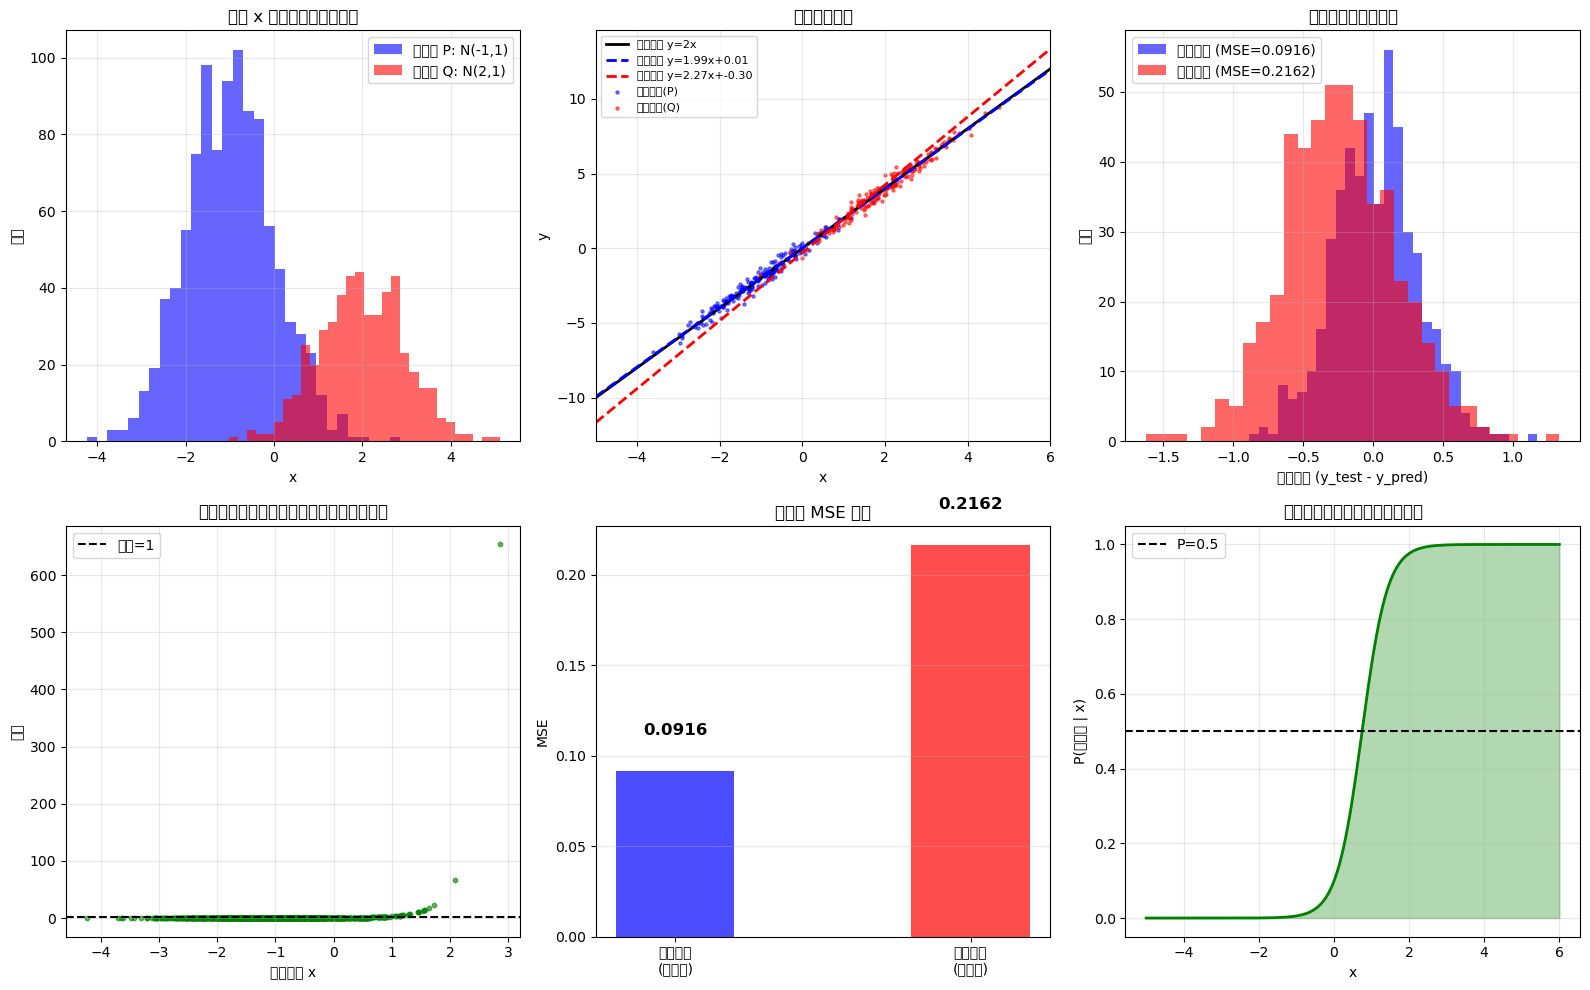

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ============================================
# 1. 构造数据集
# ============================================
np.random.seed(42)

# 训练集 P：x ~ N(-1, 1)，y = 2x + 噪声
n_train = 1000
x_train = np.random.randn(n_train, 1) * 1 + (-1)  # N(-1, 1)
epsilon_train = np.random.randn(n_train, 1) * 0.3
y_train = 2 * x_train + epsilon_train

# 测试集 Q：x ~ N(2, 1)（发生协变量偏移）
n_test = 500
x_test = np.random.randn(n_test, 1) * 1 + 2  # N(2, 1)
epsilon_test = np.random.randn(n_test, 1) * 0.3
y_test = 2 * x_test + epsilon_test

print(f"训练集 P：x ~ N(-1, 1)，样本数 {n_train}")
print(f"  训练集 x 均值: {x_train.mean():.2f}, 标准差: {x_train.std():.2f}")
print(f"\n测试集 Q：x ~ N(2, 1)，样本数 {n_test}")
print(f"  测试集 x 均值: {x_test.mean():.2f}, 标准差: {x_test.std():.2f}")
print(f"\n注意：训练集和测试集的 x 分布明显不同（协变量偏移）")

# ============================================
# 2. 基线模型：普通线性回归
# ============================================
# 最小二乘解：w = (X^T X)^{-1} X^T y
X_train_aug = np.hstack([x_train, np.ones((n_train, 1))])  # 加偏置列
X_test_aug = np.hstack([x_test, np.ones((n_test, 1))])

# 普通最小二乘
theta_baseline = np.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train
w_baseline, b_baseline = theta_baseline[0, 0], theta_baseline[1, 0]

# 预测
y_pred_baseline = X_test_aug @ theta_baseline

# 计算 MSE
mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)

print(f"\n基线模型（无校正）：")
print(f"  估计参数：w = {w_baseline:.4f}, b = {b_baseline:.4f}")
print(f"  真实参数：w = 2.0000, b = 0.0000")
print(f"  测试集 MSE: {mse_baseline:.4f}")

# ============================================
# 3. 训练逻辑回归分类器区分 P 和 Q
# ============================================
# 合并数据
x_combined = np.vstack([x_train, x_test])
# 标签：P(训练集) = 0, Q(测试集) = 1
labels = np.hstack([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归
clf = LogisticRegression(random_state=42)
clf.fit(x_combined, labels)

# 预测概率
prob_test_given_x = clf.predict_proba(x_train)[:, 1]  # P(Q|x) 对训练样本
prob_train_given_x = clf.predict_proba(x_train)[:, 0]  # P(P|x) 对训练样本

# 计算权重：w ∝ P(test|x) / P(train|x)
weights = prob_test_given_x / (prob_train_given_x + 1e-10)
# 归一化权重，使均值为1
weights = weights / weights.mean()

print(f"\n权重统计：")
print(f"  权重均值: {weights.mean():.4f}")
print(f"  权重范围: [{weights.min():.4f}, {weights.max():.4f}]")
print(f"  权重标准差: {weights.std():.4f}")

# ============================================
# 4. 加权线性回归（加权最小二乘）
# ============================================
# 加权最小二乘：θ = (X^T W X)^{-1} X^T W y
W = np.diag(weights.flatten())

theta_weighted = np.linalg.inv(X_train_aug.T @ W @ X_train_aug) @ X_train_aug.T @ W @ y_train
w_weighted, b_weighted = theta_weighted[0, 0], theta_weighted[1, 0]

# 预测
y_pred_weighted = X_test_aug @ theta_weighted

# 计算 MSE
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)

print(f"\n加权模型（校正后）：")
print(f"  估计参数：w = {w_weighted:.4f}, b = {b_weighted:.4f}")
print(f"  真实参数：w = 2.0000, b = 0.0000")
print(f"  测试集 MSE: {mse_weighted:.4f}")

# ============================================
# 5. 对比结果
# ============================================
print("\n" + "=" * 60)
print("结果对比：")
print(f"基线模型 MSE: {mse_baseline:.4f}")
print(f"加权模型 MSE: {mse_weighted:.4f}")
print(f"MSE 改善: {mse_baseline - mse_weighted:.4f} ({(1 - mse_weighted/mse_baseline)*100:.2f}%)")
print("=" * 60)

# ============================================
# 6. 可视化
# ============================================
plt.figure(figsize=(16, 10))

# 图1：数据分布对比
plt.subplot(2, 3, 1)
plt.hist(x_train, bins=30, alpha=0.6, label='训练集 P: N(-1,1)', color='blue')
plt.hist(x_test, bins=30, alpha=0.6, label='测试集 Q: N(2,1)', color='red')
plt.xlabel('x')
plt.ylabel('频数')
plt.title('特征 x 的分布：协变量偏移')
plt.legend()
plt.grid(True, alpha=0.3)

# 图2：真实函数与两个模型对比
plt.subplot(2, 3, 2)
x_plot = np.linspace(-5, 6, 200).reshape(-1, 1)
y_true = 2 * x_plot
y_baseline_plot = w_baseline * x_plot + b_baseline
y_weighted_plot = w_weighted * x_plot + b_weighted

plt.plot(x_plot, y_true, 'k-', linewidth=2, label='真实函数 y=2x')
plt.plot(x_plot, y_baseline_plot, 'b--', linewidth=2, label=f'基线模型 y={w_baseline:.2f}x+{b_baseline:.2f}')
plt.plot(x_plot, y_weighted_plot, 'r--', linewidth=2, label=f'加权模型 y={w_weighted:.2f}x+{b_weighted:.2f}')
plt.scatter(x_train[:200], y_train[:200], c='blue', s=5, alpha=0.5, label='训练样本(P)')
plt.scatter(x_test[:200], y_test[:200], c='red', s=5, alpha=0.5, label='测试样本(Q)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('模型拟合对比')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xlim([-5, 6])

# 图3：预测误差分布
plt.subplot(2, 3, 3)
errors_baseline = (y_test - y_pred_baseline).flatten()
errors_weighted = (y_test - y_pred_weighted).flatten()
plt.hist(errors_baseline, bins=30, alpha=0.6, label=f'基线模型 (MSE={mse_baseline:.4f})', color='blue')
plt.hist(errors_weighted, bins=30, alpha=0.6, label=f'加权模型 (MSE={mse_weighted:.4f})', color='red')
plt.xlabel('预测误差 (y_test - y_pred)')
plt.ylabel('频数')
plt.title('测试集预测误差分布')
plt.legend()
plt.grid(True, alpha=0.3)

# 图4：权重与 x 的关系
plt.subplot(2, 3, 4)
plt.scatter(x_train.flatten(), weights, c='green', s=10, alpha=0.6)
plt.axhline(y=1, color='black', linestyle='--', label='权重=1')
plt.xlabel('训练样本 x')
plt.ylabel('权重')
plt.title('样本权重分布（越接近测试分布权重越大）')
plt.legend()
plt.grid(True, alpha=0.3)

# 图5：MSE 对比柱状图
plt.subplot(2, 3, 5)
models = ['基线模型\n(无校正)', '加权模型\n(有校正)']
mses = [mse_baseline, mse_weighted]
colors = ['blue', 'red']
bars = plt.bar(models, mses, color=colors, alpha=0.7, width=0.4)
plt.ylabel('MSE')
plt.title('测试集 MSE 对比')
for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{mse:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 图6：分类器输出的 P(test|x) 随 x 的变化
plt.subplot(2, 3, 6)
x_prob_plot = np.linspace(-5, 6, 200).reshape(-1, 1)
prob_test = clf.predict_proba(x_prob_plot)[:, 1]
plt.plot(x_prob_plot, prob_test, 'g-', linewidth=2)
plt.fill_between(x_prob_plot.flatten(), 0, prob_test, alpha=0.3, color='green')
plt.axhline(y=0.5, color='black', linestyle='--', label='P=0.5')
plt.xlabel('x')
plt.ylabel('P(测试集 | x)')
plt.title('逻辑回归：区分训练集和测试集')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()